# Walmart M5 Demand Forecasting — Modeling

## Business Objective

Notebook 03 created a model-ready feature table using historical demand, calendar patterns, events, SNAP, prices, weather, and economic data.

This notebook trains and compares forecasting models that predict:

`units_sold`

The modeling workflow focuses on:

- time-based train / validation / test splits
- naive forecasting baselines
- preprocessing categorical features
- gradient-boosting demand models
- Poisson count-based modeling
- MAE, RMSE, WAPE, and RMSLE
- validation-based model selection
- final holdout test evaluation
- error analysis
- permutation feature importance
- saving the selected model and test predictions

> **Important:** This is a time-series forecasting problem. We do **not** use a random train/test split.

## 1. Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

## 2. Define Project Paths

Notebook 03 saved a processed feature dataset for the selected development store and item sample.

The default file below matches the Notebook 03 development configuration:

- Store: `CA_1`
- Items: `200`

Change the filename if Notebook 03 was run with a different configuration.

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"

FEATURE_FILE = (
    PROCESSED_DIR
    / "features_CA_1_200_items.csv"
)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_MODEL_FILE = MODEL_DIR / "demand_forecast_model.joblib"
METADATA_FILE = MODEL_DIR / "demand_forecast_model_metadata.json"
TEST_PREDICTIONS_FILE = OUTPUT_DIR / "test_predictions.csv"

## 3. Load Feature-Engineered Data

The date column is converted back to datetime after reading the CSV.

In [3]:
df = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["date"],
)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Products:", df["item_id"].nunique())
print("Stores:", df["store_id"].nunique())

df.head()

Dataset shape: (382600, 47)
Date range: 2011-02-26 00:00:00 to 2016-05-22 00:00:00
Products: 200
Stores: 1


,date,item_id,dept_id,cat_id,store_id,state_id,units_sold,lag_1,lag_7,lag_14,...,price_change,price_change_pct,temperature_max,temperature_min,precipitation,snowfall,wind_speed_max,CPIAUCSL,UNRATE,FEDFUNDS
0,2011-02-26,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2,4.0,1.0,3.0,...,0.0,0.0,10.6,2.2,13.6,0.0,18.5,221.187,9.1,0.17
1,2011-02-26,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,1,0.0,0.0,0.0,...,0.0,0.0,10.6,2.2,13.6,0.0,18.5,221.187,9.1,0.17
2,2011-02-26,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,1,0.0,2.0,1.0,...,0.0,0.0,10.6,2.2,13.6,0.0,18.5,221.187,9.1,0.17
3,2011-02-26,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,0,0.0,0.0,0.0,...,NaN,NaN,10.6,2.2,13.6,0.0,18.5,221.187,9.1,0.17
4,2011-02-26,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,3,1.0,1.0,6.0,...,0.0,0.0,10.6,2.2,13.6,0.0,18.5,221.187,9.1,0.17


## 4. Modeling Sanity Checks

Before training, confirm:

- the target exists
- dates are valid
- target values are non-negative
- date-item-store keys remain unique

In [4]:
TARGET = "units_sold"

required_columns = {
    "date",
    "item_id",
    "store_id",
    TARGET,
    "lag_7",
    "lag_28",
}

missing_required = required_columns - set(df.columns)

if missing_required:
    raise ValueError(
        f"Missing required modeling columns: {sorted(missing_required)}"
    )

if df["date"].isna().any():
    raise ValueError("Missing dates found.")

if df[TARGET].isna().any():
    raise ValueError("Missing target values found.")

if (df[TARGET] < 0).any():
    raise ValueError("Negative target values found.")

duplicate_keys = df.duplicated(
    subset=["date", "item_id", "store_id"]
).sum()

if duplicate_keys > 0:
    raise ValueError(
        f"Found {duplicate_keys:,} duplicate date-item-store rows."
    )

print("PASS: modeling dataset sanity checks")

PASS: modeling dataset sanity checks


## 5. Time-Based Train / Validation / Test Split

The forecast horizon for the project is **28 days**.

We therefore reserve:

- the **last 28 days** as the untouched test set
- the **previous 28 days** as validation
- all earlier data as training

The validation set is used to compare models.

The test set is used only after a model has been selected.

In [5]:
MAX_DATE = df["date"].max()

TEST_DAYS = 28
VALIDATION_DAYS = 28

test_start = (
    MAX_DATE
    - pd.Timedelta(days=TEST_DAYS - 1)
)

validation_end = (
    test_start
    - pd.Timedelta(days=1)
)

validation_start = (
    validation_end
    - pd.Timedelta(days=VALIDATION_DAYS - 1)
)

train = df.loc[
    df["date"] < validation_start
].copy()

validation = df.loc[
    (df["date"] >= validation_start)
    & (df["date"] <= validation_end)
].copy()

test = df.loc[
    df["date"] >= test_start
].copy()

print("TRAIN")
print(train["date"].min(), "to", train["date"].max())
print("Rows:", f"{len(train):,}")

print("\nVALIDATION")
print(validation["date"].min(), "to", validation["date"].max())
print("Rows:", f"{len(validation):,}")

print("\nTEST")
print(test["date"].min(), "to", test["date"].max())
print("Rows:", f"{len(test):,}")

TRAIN
2011-02-26 00:00:00 to 2016-03-27 00:00:00
Rows: 371,400

VALIDATION
2016-03-28 00:00:00 to 2016-04-24 00:00:00
Rows: 5,600

TEST
2016-04-25 00:00:00 to 2016-05-22 00:00:00
Rows: 5,600


### Split Visualization

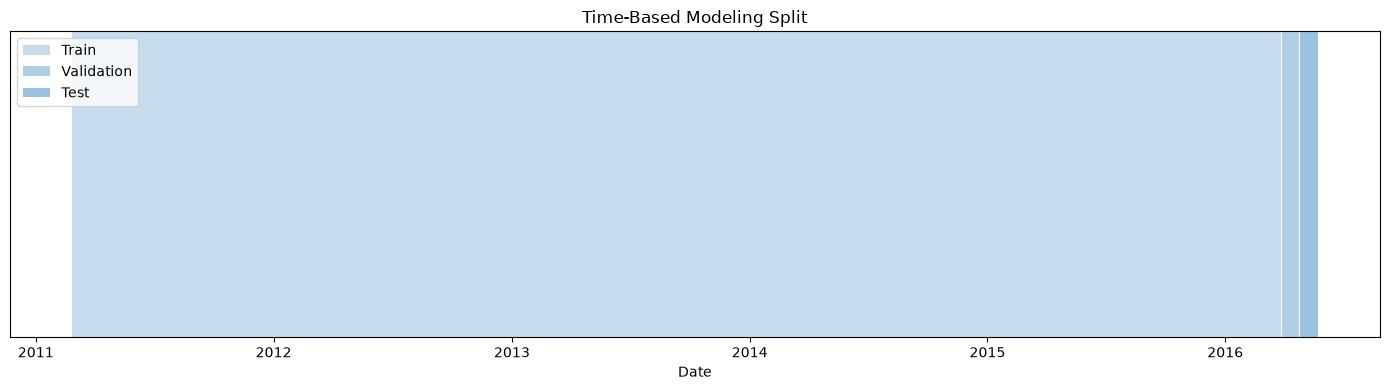

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.axvspan(
    train["date"].min(),
    train["date"].max(),
    alpha=0.25,
    label="Train",
)
ax.axvspan(
    validation["date"].min(),
    validation["date"].max(),
    alpha=0.35,
    label="Validation",
)
ax.axvspan(
    test["date"].min(),
    test["date"].max(),
    alpha=0.45,
    label="Test",
)

ax.set_title("Time-Based Modeling Split")
ax.set_xlabel("Date")
ax.set_yticks([])
ax.legend()

plt.tight_layout()
plt.show()

## 6. Define Evaluation Metrics

We use several complementary metrics.

### MAE
Average absolute prediction error in units.

### RMSE
Penalizes large misses more heavily than MAE.

### WAPE
Total absolute error divided by total actual demand. This is easy to interpret as a percentage-like error measure.

### RMSLE
Compares predictions on a logarithmic scale and is useful when demand contains many zeros and large spikes.

All model predictions are clipped at zero because negative unit demand is not meaningful.

In [7]:
def evaluate_predictions(
    y_true,
    y_pred,
):
    y_true = np.asarray(y_true)
    y_pred = np.clip(
        np.asarray(y_pred),
        0,
        None,
    )

    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred,
        )
    )

    denominator = np.abs(y_true).sum()

    wape = (
        np.abs(y_true - y_pred).sum()
        / denominator
        if denominator != 0
        else np.nan
    )

    rmsle = np.sqrt(
        mean_squared_log_error(
            y_true,
            y_pred,
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "RMSLE": rmsle,
    }

## 7. Naive Forecasting Baselines

A machine-learning model should outperform simple forecasting rules.

We compare two baselines:

- `lag_7`: predict the same demand as one week ago
- `lag_28`: predict the same demand as four weeks ago

In [8]:
baseline_results = []

for baseline_name in [
    "lag_7",
    "lag_28",
]:
    metrics = evaluate_predictions(
        validation[TARGET],
        validation[baseline_name],
    )

    baseline_results.append({
        "model": baseline_name,
        **metrics,
    })

baseline_results_df = pd.DataFrame(
    baseline_results
)

baseline_results_df

,model,MAE,RMSE,WAPE,RMSLE
0,lag_7,1.412143,2.739200,1.097419,0.749882
1,lag_28,1.439286,2.756421,1.118512,0.741798


## 8. Select Modeling Features

The model should not use:

- the target itself
- the raw date
- fields that exist only for bookkeeping

Categorical variables are kept and encoded inside the modeling pipeline.

The historical lags, rolling statistics, price signals, weather, calendar variables, events, SNAP, and economic indicators remain available to the model.

In [9]:
DROP_FROM_FEATURES = [
    TARGET,
    "date",
]

feature_columns = [
    column
    for column in df.columns
    if column not in DROP_FROM_FEATURES
]

X_train = train[feature_columns].copy()
y_train = train[TARGET].copy()

X_validation = validation[feature_columns].copy()
y_validation = validation[TARGET].copy()

X_test = test[feature_columns].copy()
y_test = test[TARGET].copy()

print("Features:", len(feature_columns))
print("Training rows:", f"{len(X_train):,}")

Features: 45
Training rows: 371,400


## 9. Identify Categorical and Numeric Features

String/object columns need to be encoded before gradient boosting.

`OrdinalEncoder` assigns an integer code to each category and safely maps previously unseen categories to `-1`.

Numeric features pass through unchanged. `HistGradientBoostingRegressor` can handle numeric `NaN` values directly.

In [10]:
categorical_features = (
    X_train
    .select_dtypes(
        include=[
            "object",
            "string",
            "category",
        ]
    )
    .columns
    .tolist()
)

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'holiday_name']

Numeric features:
['lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'zero_sales_share_28', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'year', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'has_any_event', 'is_us_holiday', 'snap', 'sell_price', 'price_available', 'previous_sell_price', 'price_change', 'price_change_pct', 'temperature_max', 'temperature_min', 'precipitation', 'snowfall', 'wind_speed_max', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS']


## 10. Build the Preprocessing Pipeline

Missing categorical values are converted to an explicit label so event/holiday absence remains meaningful.

Numeric missing values remain `NaN` because histogram gradient boosting can handle them.

In [11]:
for frame in [
    X_train,
    X_validation,
    X_test,
]:
    frame[categorical_features] = (
        frame[categorical_features]
        .fillna("__MISSING__")
        .astype(str)
    )

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ],
    remainder="drop",
)

## 11. Model 1 — Histogram Gradient Boosting

This model captures nonlinear relationships and feature interactions while remaining efficient enough for the development dataset.

Examples of relationships it may learn include:

- lagged demand + weekday
- price + item
- SNAP + state
- weather + season
- events + recent demand

In [12]:
hgb_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)

hgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", hgb_model),
    ]
)

hgb_pipeline.fit(
    X_train,
    y_train,
)

hgb_validation_pred = np.clip(
    hgb_pipeline.predict(X_validation),
    0,
    None,
)

hgb_metrics = evaluate_predictions(
    y_validation,
    hgb_validation_pred,
)

hgb_metrics

{'MAE': 1.075188348643003,
 'RMSE': np.float64(1.8531581499789433),
 'WAPE': np.float64(0.8355613034139352),
 'RMSLE': np.float64(0.5569676171930251)}

## 12. Model 2 — Poisson Histogram Gradient Boosting

Demand is a non-negative count-like target with many zeros.

A Poisson loss can therefore be a useful alternative to ordinary squared-error regression.

In [13]:
poisson_model = HistGradientBoostingRegressor(
    loss="poisson",
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)

poisson_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", poisson_model),
    ]
)

poisson_pipeline.fit(
    X_train,
    y_train,
)

poisson_validation_pred = np.clip(
    poisson_pipeline.predict(X_validation),
    0,
    None,
)

poisson_metrics = evaluate_predictions(
    y_validation,
    poisson_validation_pred,
)

poisson_metrics

{'MAE': 1.072846013189959,
 'RMSE': np.float64(1.830647011548037),
 'WAPE': np.float64(0.8337410038667459),
 'RMSLE': np.float64(0.5590811815099453)}

## 13. Compare Validation Results

The selected model should beat the naive baselines and perform well across several metrics.

For this development notebook, **RMSE** is used as the primary model-selection metric because large forecast misses are especially important for inventory and pricing decisions.

In [14]:
model_results = baseline_results.copy()

model_results.extend([
    {
        "model": "hist_gradient_boosting",
        **hgb_metrics,
    },
    {
        "model": "poisson_hist_gradient_boosting",
        **poisson_metrics,
    },
])

validation_results = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

validation_results

,model,MAE,RMSE,WAPE,RMSLE
0,poisson_hist_gradient_boosting,1.072846,1.830647,0.833741,0.559081
1,hist_gradient_boosting,1.075188,1.853158,0.835561,0.556968
2,lag_7,1.412143,2.739200,1.097419,0.749882
3,lag_28,1.439286,2.756421,1.118512,0.741798


### Validation Comparison Chart

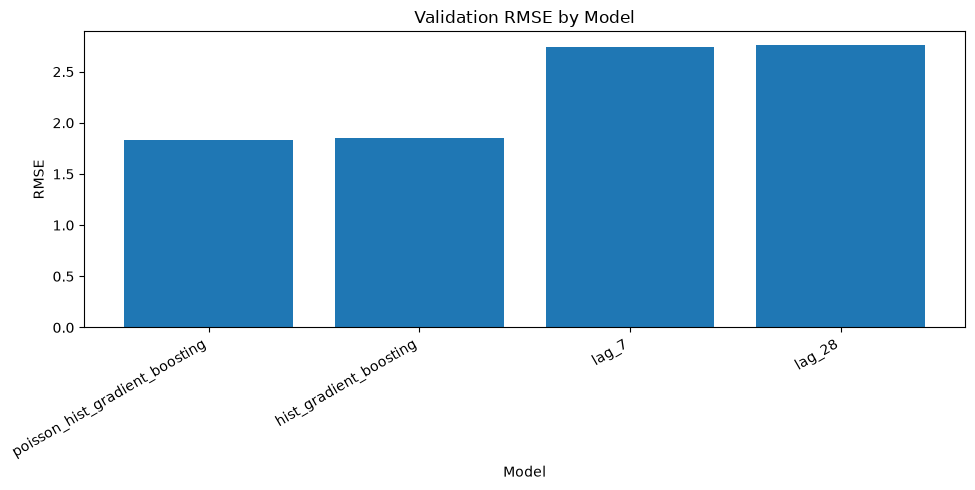

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    validation_results["model"],
    validation_results["RMSE"],
)

ax.set_title("Validation RMSE by Model")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 14. Select the Best Machine-Learning Model

Only the trained machine-learning models are eligible for persistence.

The naive baselines remain benchmarks.

The machine-learning model with the lower validation RMSE is selected.

In [16]:
ml_candidates = {
    "hist_gradient_boosting": {
        "pipeline": hgb_pipeline,
        "metrics": hgb_metrics,
    },
    "poisson_hist_gradient_boosting": {
        "pipeline": poisson_pipeline,
        "metrics": poisson_metrics,
    },
}

selected_model_name = min(
    ml_candidates,
    key=lambda name:
        ml_candidates[name]["metrics"]["RMSE"],
)

selected_pipeline = (
    ml_candidates[selected_model_name]["pipeline"]
)

print("Selected model:", selected_model_name)
print(
    "Validation RMSE:",
    ml_candidates[selected_model_name]["metrics"]["RMSE"],
)

Selected model: poisson_hist_gradient_boosting
Validation RMSE: 1.830647011548037


## 15. Final Test Evaluation

The test set has remained untouched during model comparison.

Now the selected model is evaluated once on the final 28-day holdout period.

In [17]:
test_predictions = np.clip(
    selected_pipeline.predict(X_test),
    0,
    None,
)

test_metrics = evaluate_predictions(
    y_test,
    test_predictions,
)

pd.DataFrame(
    [
        {
            "model": selected_model_name,
            **test_metrics,
        }
    ]
)

,model,MAE,RMSE,WAPE,RMSLE
0,poisson_hist_gradient_boosting,1.252022,2.206089,0.807384,0.606301


## 16. Compare Actual vs. Predicted Total Demand

Aggregate predictions across products to inspect whether the selected model captures the overall 28-day demand pattern.

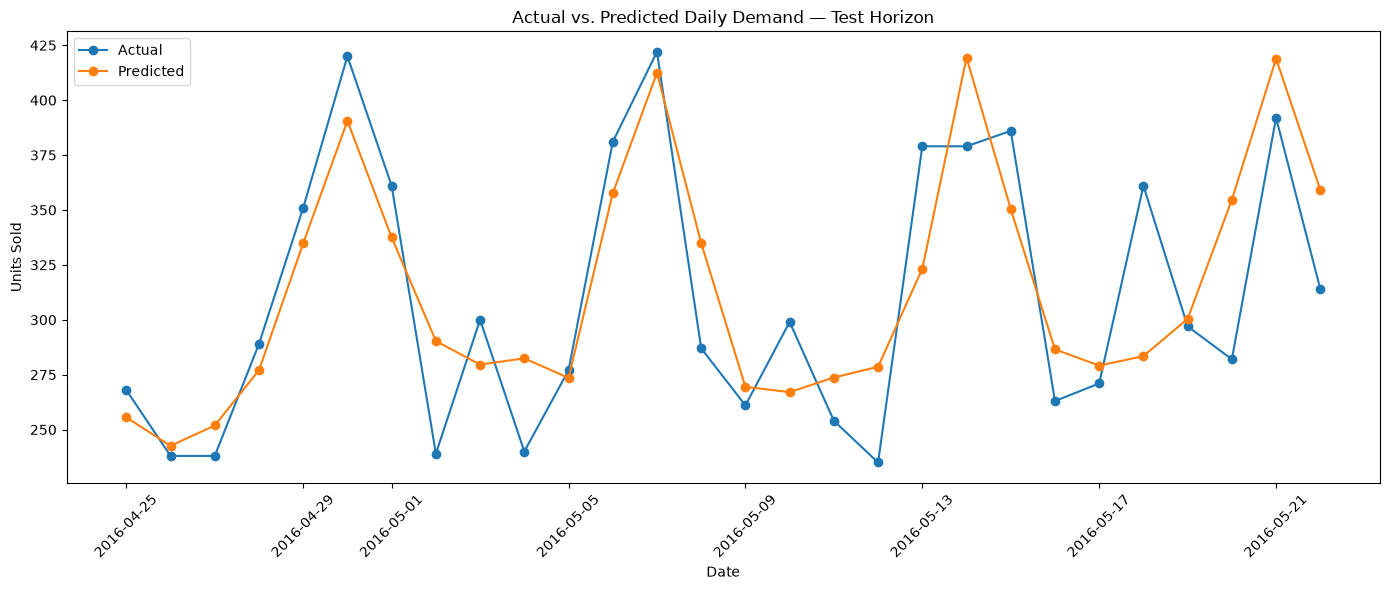

In [18]:
test_results = test[
    [
        "date",
        "item_id",
        "store_id",
        TARGET,
    ]
].copy()

test_results["prediction"] = (
    test_predictions
)

daily_test = (
    test_results
    .groupby(
        "date",
        as_index=False,
    )[
        [
            TARGET,
            "prediction",
        ]
    ]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_test["date"],
    daily_test[TARGET],
    marker="o",
    label="Actual",
)

ax.plot(
    daily_test["date"],
    daily_test["prediction"],
    marker="o",
    label="Predicted",
)

ax.set_title(
    "Actual vs. Predicted Daily Demand — Test Horizon"
)
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Prediction Error Distribution

Residuals are:

`actual - predicted`

Positive residuals mean the model **underpredicted** demand.

Negative residuals mean the model **overpredicted** demand.

In [19]:
test_results["residual"] = (
    test_results[TARGET]
    - test_results["prediction"]
)

test_results["absolute_error"] = (
    test_results["residual"].abs()
)

test_results[
    [
        "residual",
        "absolute_error",
    ]
].describe()

,residual,absolute_error
count,5600.000000,5600.000000
mean,-0.018008,1.252022
std,2.206212,1.816551
min,-12.351835,0.000273
25%,-0.919966,0.373558
50%,-0.310399,0.825119
75%,0.536862,1.482551
max,75.766550,75.766550


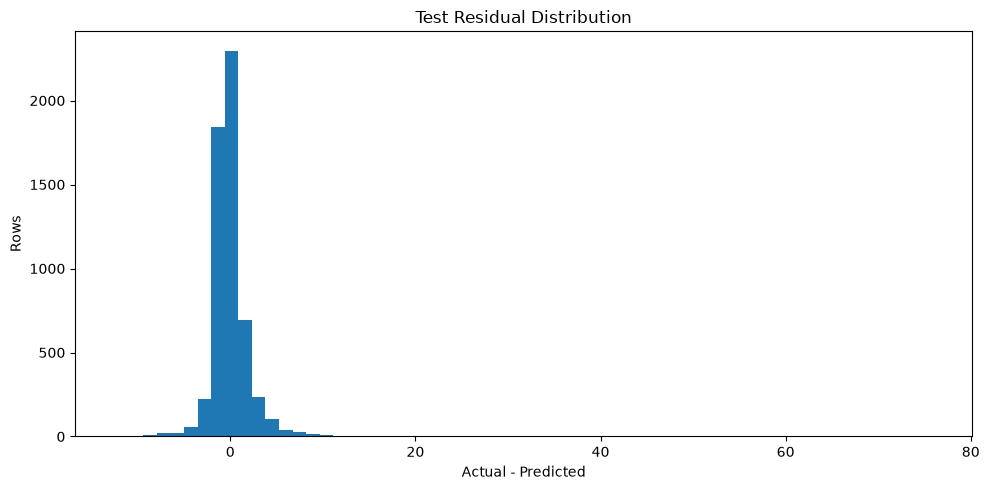

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    test_results["residual"],
    bins=60,
)

ax.set_title("Test Residual Distribution")
ax.set_xlabel("Actual - Predicted")
ax.set_ylabel("Rows")

plt.tight_layout()
plt.show()

## 18. Error by Product

A strong aggregate forecast can still perform poorly for particular products.

This section identifies products with the largest average absolute errors.

In [21]:
product_error = (
    test_results
    .groupby(
        "item_id",
        as_index=False,
    )
    .agg(
        actual_units=(TARGET, "sum"),
        predicted_units=("prediction", "sum"),
        mae=("absolute_error", "mean"),
    )
    .sort_values(
        "mae",
        ascending=False,
    )
)

product_error.head(20)

,item_id,actual_units,predicted_units,mae
17,FOODS_1_019,205,216.242763,5.939075
86,FOODS_1_088,112,47.986075,4.335535
84,FOODS_1_086,121,131.152087,4.169714
16,FOODS_1_018,243,262.046716,4.145152
53,FOODS_1_055,108,70.595827,4.050755
83,FOODS_1_085,184,222.399031,4.013459
97,FOODS_1_099,208,257.434513,3.747711
41,FOODS_1_043,220,190.790493,3.666530
44,FOODS_1_046,199,234.795631,3.644816
196,FOODS_1_200,207,247.527744,3.012837


## 19. Error by Demand Level

Intermittent and low-demand products may behave differently from higher-volume products.

Create simple demand groups using each product's average training demand.

In [22]:
training_item_demand = (
    train
    .groupby(
        "item_id",
        as_index=False,
    )[TARGET]
    .mean()
    .rename(
        columns={
            TARGET: "average_training_demand"
        }
    )
)

test_error_by_item = test_results.merge(
    training_item_demand,
    on="item_id",
    how="left",
    validate="many_to_one",
)

test_error_by_item["demand_group"] = pd.qcut(
    test_error_by_item[
        "average_training_demand"
    ],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High",
    ],
    duplicates="drop",
)

demand_group_error = (
    test_error_by_item
    .groupby(
        "demand_group",
        observed=True,
    )
    .agg(
        rows=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        actual_units=(TARGET, "sum"),
        predicted_units=("prediction", "sum"),
    )
    .reset_index()
)

demand_group_error

,demand_group,rows,mae,actual_units,predicted_units
0,Low,1876,0.709527,1228,1265.973186
1,Medium,1876,1.115013,2294,2182.914405
2,High,1848,1.941821,5162,5335.958268


## 20. Permutation Feature Importance

`HistGradientBoostingRegressor` does not expose traditional tree feature importance.

Permutation importance measures how much validation performance worsens when one input column is randomly shuffled.

To keep the notebook practical, importance is calculated on a validation sample.

In [23]:
IMPORTANCE_SAMPLE_SIZE = min(
    5_000,
    len(X_validation),
)

importance_sample = X_validation.sample(
    n=IMPORTANCE_SAMPLE_SIZE,
    random_state=42,
)

importance_target = y_validation.loc[
    importance_sample.index
]

importance_result = permutation_importance(
    selected_pipeline,
    importance_sample,
    importance_target,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": importance_result.importances_mean,
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance
0,rolling_mean_28,0.111283
1,zero_sales_share_28,0.078211
2,rolling_mean_7,0.050994
3,rolling_std_7,0.022796
4,temperature_max,0.008781
5,dow_sin,0.004231
6,rolling_std_28,0.003777
7,temperature_min,0.003039
8,dow_cos,0.001907
9,day_of_week,0.001509


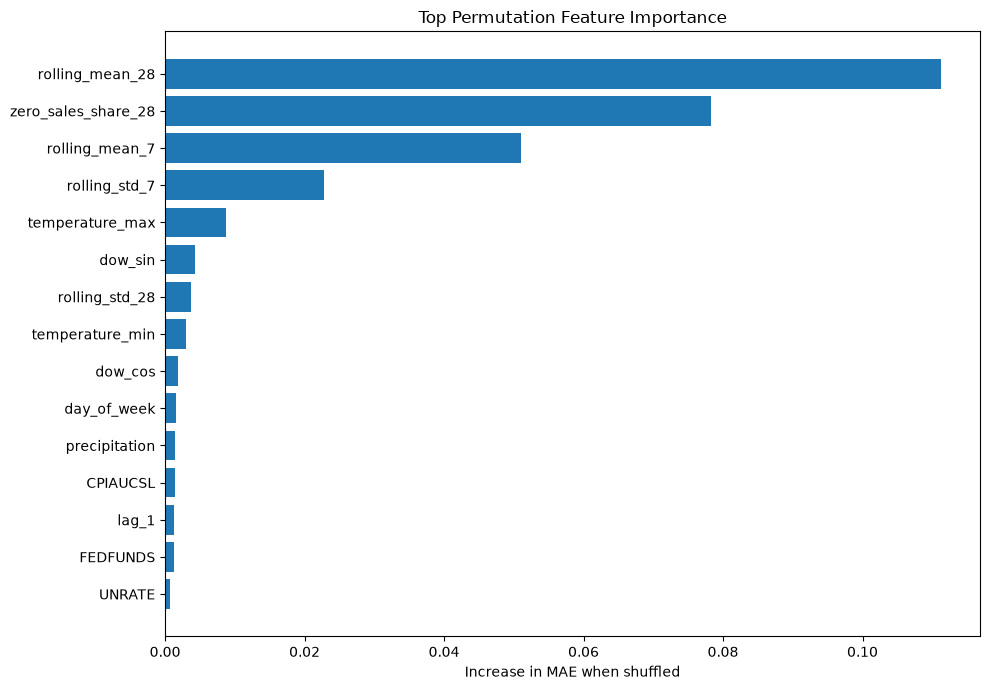

In [24]:
top_features = importance_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1],
)

ax.set_title(
    "Top Permutation Feature Importance"
)
ax.set_xlabel(
    "Increase in MAE when shuffled"
)

plt.tight_layout()
plt.show()

## 21. Refit the Selected Model on Train + Validation

Once the model family has been selected, retrain it using both the training and validation periods before saving it.

The final test period is still excluded from training.

In [25]:
train_validation = pd.concat(
    [
        train,
        validation,
    ],
    ignore_index=True,
)

X_train_validation = (
    train_validation[
        feature_columns
    ]
    .copy()
)

y_train_validation = (
    train_validation[TARGET]
    .copy()
)

X_train_validation[
    categorical_features
] = (
    X_train_validation[
        categorical_features
    ]
    .fillna("__MISSING__")
    .astype(str)
)

selected_pipeline.fit(
    X_train_validation,
    y_train_validation,
)

print(
    "Refit rows:",
    f"{len(X_train_validation):,}",
)

Refit rows: 377,000


## 22. Save the Selected Model

The complete scikit-learn pipeline is saved, including:

- categorical preprocessing
- the fitted forecasting model

This allows future code to call `.predict()` using the same input feature columns.

In [26]:
joblib.dump(
    selected_pipeline,
    SELECTED_MODEL_FILE,
)

model_metadata = {
    "selected_model": selected_model_name,
    "target": TARGET,
    "feature_columns": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "train_end_date": str(
        validation_end.date()
    ),
    "test_start_date": str(
        test_start.date()
    ),
    "test_end_date": str(
        MAX_DATE.date()
    ),
    "validation_metrics": (
        ml_candidates[
            selected_model_name
        ]["metrics"]
    ),
    "test_metrics": test_metrics,
}

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metadata,
        file,
        indent=2,
    )

print("Saved model:", SELECTED_MODEL_FILE)
print("Saved metadata:", METADATA_FILE)

Saved model: ..\models\demand_forecast_model.joblib
Saved metadata: ..\models\demand_forecast_model_metadata.json


## 23. Save Test Predictions

The test predictions are saved so Notebook 05 can perform deeper evaluation without retraining the model.

In [27]:
test_results.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False,
)

print(
    "Saved test predictions:",
    TEST_PREDICTIONS_FILE,
)
print(
    "Prediction rows:",
    f"{len(test_results):,}",
)

Saved test predictions: ..\outputs\modeling\test_predictions.csv
Prediction rows: 5,600


## 24. Modeling Findings

### Baseline Performance

The naive baselines provide a simple benchmark for determining whether the machine-learning models add forecasting value.

- `lag_7`: **MAE 1.412**, **RMSE 2.739**, **WAPE 109.7%**, **RMSLE 0.750**
- `lag_28`: **MAE 1.439**, **RMSE 2.756**, **WAPE 111.9%**, **RMSLE 0.742**

Both machine-learning models substantially outperform these naive validation baselines.

### Machine-Learning Models

**Histogram Gradient Boosting**

- Validation MAE: **1.075**
- Validation RMSE: **1.853**
- Validation WAPE: **83.6%**
- Validation RMSLE: **0.557**

**Poisson Histogram Gradient Boosting**

- Validation MAE: **1.073**
- Validation RMSE: **1.831**
- Validation WAPE: **83.4%**
- Validation RMSLE: **0.559**

The selected model is **Poisson Histogram Gradient Boosting** because it achieved the lowest validation RMSE.

### Final Test Performance

On the untouched 28-day test period, the selected model achieved:

- Test MAE: **1.252**
- Test RMSE: **2.206**
- Test WAPE: **80.7%**
- Test RMSLE: **0.606**

The test period contains **5,600 item-day predictions** across 200 products.

### Error Behavior

Forecasting error is not evenly distributed across products.

The largest product-level MAEs include:

- `FOODS_1_019`: **5.94**
- `FOODS_1_088`: **4.34**
- `FOODS_1_086`: **4.17**
- `FOODS_1_018`: **4.15**
- `FOODS_1_055`: **4.05**

Demand-level analysis shows:

- Low-demand MAE: **0.710**
- Medium-demand MAE: **1.115**
- High-demand MAE: **1.942**

The model therefore performs better on lower-demand products and has more difficulty with higher-volume or more volatile products.

The largest individual absolute error in the test set is approximately **75.77 units**, showing that unusual demand spikes remain difficult to predict.

The mean residual is approximately **-0.018 units**, suggesting little overall directional bias across the test observations.

### Feature Importance

Permutation importance shows that historical demand behavior is the strongest source of predictive information.

The most important features are:

1. `rolling_mean_28`
2. `zero_sales_share_28`
3. `rolling_mean_7`
4. `rolling_std_7`

Calendar-related signals such as `dow_sin`, `dow_cos`, and `day_of_week` contribute additional information.

External variables such as `temperature_max`, `temperature_min`, precipitation, CPI, federal funds rate, and unemployment contribute much less than recent demand history in this development sample.

### Modeling Decision

The selected Poisson Histogram Gradient Boosting model clearly outperforms the naive `lag_7` and `lag_28` validation baselines, so the model adds useful forecasting value.

The model is strong enough to continue into deeper evaluation and backtesting in Notebook 05.

However, this notebook alone does **not** establish production readiness. Important remaining questions include:

- performance across multiple historical backtest windows
- behavior on zero-demand and intermittent-demand observations
- large unexpected demand spikes
- forecast bias and calibration
- whether performance remains stable across demand levels

Notebook 05 addresses these questions before the model is allowed to feed the dynamic-pricing stage.

> **Forecasting scope:** The lag and rolling features in this development dataset are calculated from observed history available up to each row. The current evaluation therefore represents a **daily-updated forecasting workflow**, not a strict one-shot 28-day production forecast. A production multi-step forecast will require recursive forecasting, horizon-specific models, or features guaranteed to be known at the forecast origin.


## 25. Next Step

The next notebook is:

`05_model_evaluation.ipynb`

Notebook 05 will perform deeper forecasting evaluation, including:

- performance by item / category / demand level
- forecast bias
- error across the 28-day horizon
- rolling-origin backtesting
- prediction diagnostics
- comparison with naive forecasts
- final model acceptance criteria

After the forecasting model is accepted, the project moves into the **dynamic pricing layer**.